In [2]:
# !pip uninstall -y flax orbax-checkpoint jax jaxlib \
#     ml-dtypes tf-keras tensorflow tensorflow-cpu tensorflow-text \
#     tensorflow-decision-forests keras keras-hub \
#     chex optax fastai spacy tensorstore numba \
#     umap-learn pynndescent librosa shap cuml-cu12 cudf-cu12 dask-cuda

%pip install -U threadpoolctl joblib
#%pip install --force-reinstall numpy==1.26.4
%pip install --upgrade scikit-learn
%pip install -U imbalanced-learn

%pip install --upgrade --force-reinstall \
    numpy \
    scipy \
    matplotlib \
    seaborn \
    pandas \
    tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.24.4-cp38-cp38-macosx_11_0_arm64.whl.metadata (5.6 kB)
  Using cached scipy-1.10.1-cp38-cp38-macosx_12_0_arm64.whl.metadata (53 kB)
  Using cached matplotlib-3.7.5-cp38-cp38-macosx_11_0_arm64.whl.metadata (5.7 kB)
  Using cached pandas-2.0.3-cp38-cp38-macosx_11_0_arm64.whl.metadata (18 kB)
  Using cached tensorflow-2.13.1-cp38-cp38-macosx_12_0_arm64.whl.metadata (2.6 kB)
  Using cached contourpy-1.1.1-cp38-cp38-macosx_11_0_arm64.whl.metadata (5.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.57.0-cp38-cp38-macosx_10_9_universal2.whl.metadata (102 kB)
  Using cached kiwisolver-1.4.7-cp38-cp38-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pillow-10.4

In [ ]:
import importlib, random, os, numpy as np, tensorflow as tf

print("===== VERSIONS =====")
for lib in ("numpy", "pandas", "sklearn", "imblearn",
            "tensorflow", "matplotlib", "seaborn"):
    m = importlib.import_module(lib if lib != "sklearn" else "sklearn")
    print(f"{lib:17s}: {m.__version__}")

print("\n===== TensorFlow devices =====")
print(tf.config.list_physical_devices())   # ← здесь будет только CPU, и это нормально

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"\nRandom seed set to {SEED}")

===== VERSIONS =====
numpy            : 2.0.2
pandas           : 2.2.3
sklearn          : 1.6.1
imblearn         : 0.12.4
tensorflow       : 2.19.0
matplotlib       : 3.9.4
seaborn          : 0.13.2

===== TensorFlow devices =====
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

Random seed set to 42


In [37]:
# === @title Этап 2 (Kaggle API) — Ethereum Fraud Detection ===
# 0. (если делали раньше, шаги с pip и токеном можно пропустить)

# — 0.1 Установка библиотеки kaggle —
%pip install --quiet kaggle

# # — 0.2 Загрузка kaggle.json (один раз за сессию Colab) —
# #    Если токен уже лежит в ~/.kaggle, эту строку можно пропустить.
# from google.colab import files, auth
# import pathlib, io, os, json, pandas as pd

# if not pathlib.Path("~/.kaggle/kaggle.json").expanduser().exists():
#     print("📂 Загрузите kaggle.json ➜")
#     token_file = files.upload()           # откроется диалог
#     if "kaggle.json" not in token_file:
#         raise ValueError("Нужно загрузить файл под именем kaggle.json")
#     pathlib.Path("~/.kaggle").expanduser().mkdir(exist_ok=True)
#     with open(pathlib.Path("~/.kaggle/kaggle.json").expanduser(), "wb") as f:
#         f.write(token_file["kaggle.json"])
#     !chmod 600 ~/.kaggle/kaggle.json
# else:
#     print("🔑 kaggle.json уже настроен")

import os
import json
import pathlib
import pandas as pd
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

# 1. Убедимся, что у нас есть файл kaggle.json (с токеном Kaggle)
kaggle_json_path = '/Users/a1234/Fraud/kaggle.json'

if not os.path.exists(kaggle_json_path):
    raise FileNotFoundError("Файл 'kaggle.json' не найден. Пожалуйста, скачайте его с вашего аккаунта Kaggle.")

# 2. Конфигурируем API Kaggle с использованием токена
with open(kaggle_json_path) as f:
    kaggle_json = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_json['username']
os.environ['KAGGLE_KEY'] = kaggle_json['key']

# 3. Инициализируем API
api = KaggleApi()
api.authenticate()

# 1. Скачиваем архив датасета
slug = "vagifa/ethereum-frauddetection-dataset"
print(f"\n⬇️ Скачиваю датасет {slug} ...")
!kaggle datasets download -d {slug} -p ./data --force --quiet

# 2. Распаковываем
print("📦 Распаковываю ...")
!unzip -o ./data/*.zip -d ./data > /dev/null

# 3. Открываем transactions.csv
csv_path = "./data/transactions.csv"
if not os.path.exists(csv_path):
    # fallback: берем первый найденный CSV
    import glob
    found = glob.glob("./data/**/*.csv", recursive=True)
    if not found:
        raise RuntimeError("CSV-файлы не найдены в архиве.")
    csv_path = found[0]
print(f"✅ Нашёл CSV: {csv_path}")

df = pd.read_csv(csv_path)

# 4. Отладочная информация
print("\n===== SHAPE =====")
print(df.shape)            # ожидаем (9840, 49)

print("\n===== HEAD (5 строк) =====")
display(df.head())

print("\n===== Классовое соотношение (isFraud) =====")
if "FLAG" in df.columns:
    display((df["FLAG"].value_counts(normalize=True) * 100).round(2).rename("%"))
else:
    print("Столбец 'FLAG' не найден — проверьте структуру датасета.")

Note: you may need to restart the kernel to use updated packages.

⬇️ Скачиваю датасет vagifa/ethereum-frauddetection-dataset ...
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Dataset URL: https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset
License(s): DbCL-1.0
📦 Распаковываю ...
✅ Нашёл CSV: ./data/transaction_dataset.csv

===== SHAPE =====
(9841, 51)

===== HEAD (5 строк) =====


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS



===== Классовое соотношение (isFraud) =====


FLAG
0    77.86
1    22.14
Name: %, dtype: float64

In [59]:
import pandas as pd
df = pd.read_csv('./data/transaction_dataset.csv')

# 4. Отладочная информация
print("\n===== SHAPE =====")
print(df.shape)

print("\n===== HEAD (5 строк) =====")
display(df.head())

print("\n===== Классовое соотношение (isFraud) =====")
if "FLAG" in df.columns:
    display((df["FLAG"].value_counts(normalize=True) * 100).round(2).rename("%"))
else:
    print("Столбец 'FLAG' не найден — проверьте структуру датасета.")


===== SHAPE =====
(9841, 51)

===== HEAD (5 строк) =====


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS



===== Классовое соотношение (isFraud) =====


FLAG
0    77.86
1    22.14
Name: %, dtype: float64

In [60]:
df.drop(columns=["Unnamed: 0", "Index"], inplace=True, errors="ignore")
df['FLAG'].value_counts(normalize=True)

FLAG
0    0.778579
1    0.221421
Name: proportion, dtype: float64

==> Shape после удаления служебных колонок: (9841, 49)

===== ТОП-10 столбцов по числу NaN =====


ERC20 most sent token type     2697
ERC20_most_rec_token_type       871
ERC20 max val rec               829
ERC20 uniq rec token name       829
ERC20 uniq sent token name      829
ERC20 avg val sent contract     829
ERC20 max val sent contract     829
ERC20 min val sent contract     829
ERC20 avg val sent              829
ERC20 max val sent              829
dtype: int64

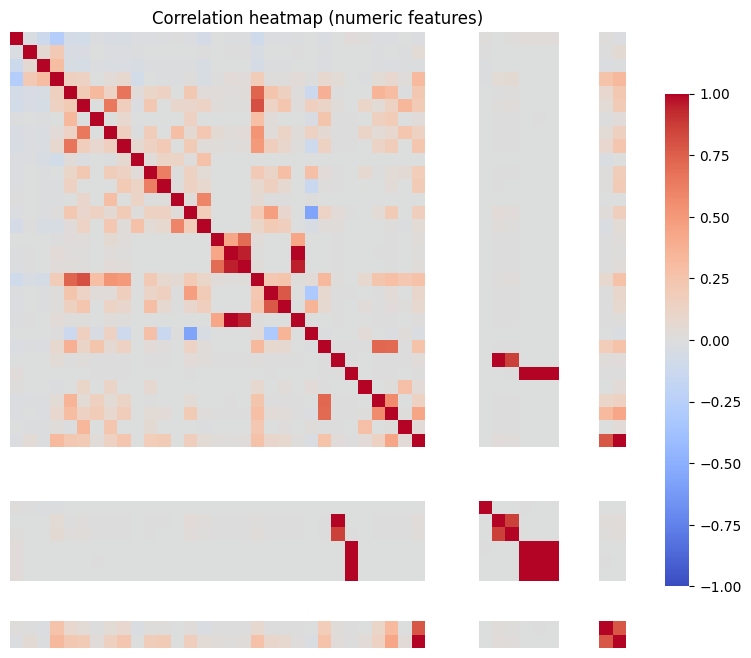


===== Признаки с нулевой дисперсией (n=7) =====
[' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx', ' ERC20 avg time between rec 2 tnx', ' ERC20 avg time between contract tnx', ' ERC20 min val sent contract', ' ERC20 max val sent contract', ' ERC20 avg val sent contract']

===== Распределение FLAG =====


FLAG
0    77.86
1    22.14
Name: %, dtype: float64

In [61]:
# === @title Этап 3: первичный анализ и инвентаризация признаков ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

# 0) Копируем исходный df (на всякий случай)
df_eda = df.copy()

# 1) Удаляем служебные колонки, если есть
svc_cols = ["Unnamed: 0", "Index"]
df_eda.drop(columns=[c for c in svc_cols if c in df_eda.columns],
            inplace=True, errors="ignore")

print("==> Shape после удаления служебных колонок:", df_eda.shape)

# 2) Проверяем пропуски
na_counts = df_eda.isna().sum()
na_nonzero = na_counts[na_counts > 0].sort_values(ascending=False)

print("\n===== ТОП-10 столбцов по числу NaN =====")
display(na_nonzero.head(10))

# 3) Корреляционная матрица Пирсона
num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr = df_eda[num_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0,
            vmax=1, vmin=-1, square=True,
            cbar_kws={"shrink": .8}, xticklabels=False, yticklabels=False)
plt.title("Correlation heatmap (numeric features)")
plt.show()

# 4) Признаки с нулевой дисперсией (постоянные значения)
zero_var = df_eda[num_cols].loc[:, df_eda[num_cols].nunique() == 1].columns.tolist()
print(f"\n===== Признаки с нулевой дисперсией (n={len(zero_var)}) =====")
print(zero_var)

# 5) Быстрый взгляд на распределение классов (FLAG)
print("\n===== Распределение FLAG =====")
display(df_eda["FLAG"].value_counts(normalize=True).rename("%").mul(100).round(2))

In [62]:
# === @title Этап 4: очистка признаков перед обучением ===

import pandas as pd, numpy as np

# 0) Копируем исходный df
df_clean = df.copy()

# 1) Убираем пробелы в заголовках и служебные поля
df_clean.columns = df_clean.columns.str.strip()
df_clean.drop(columns=["Unnamed: 0", "Index"], inplace=True, errors="ignore")

# 2) Удаляем все строковые столбцы (Address, токены и т.п.)
str_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
print("Удаляю строковые колонки:", str_cols)
df_clean = df_clean.drop(columns=str_cols)

# 3) Удаляем признаки с нулевой дисперсией
zero_var = [
    "ERC20 avg time between sent tnx",
    "ERC20 avg time between rec tnx",
    "ERC20 avg time between rec 2 tnx",
    "ERC20 avg time between contract tnx",
    "ERC20 min val sent contract",
    "ERC20 max val sent contract",
    "ERC20 avg val sent contract",
]
to_drop = [c for c in zero_var if c in df_clean.columns]
print("Удаляю zero-variance:", to_drop)
df_clean = df_clean.drop(columns=to_drop)

# 4) Заполняем все NaN медианой по столбцу
num_cols = df_clean.columns.tolist()  # теперь все — числовые
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 5) Убираем одну из пары сильнокоррелирующих признаков (|ρ| > 0.9)
corr = df_clean.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Удаляю сильно коррелирующие (>0.9):", high_corr_drop)
df_clean = df_clean.drop(columns=high_corr_drop)

# 6) Финальная проверка
print("\nИтоговая форма df_clean:", df_clean.shape)
print("Осталось NaN всего:", df_clean.isna().sum().sum())

Удаляю строковые колонки: ['Address', 'ERC20 most sent token type', 'ERC20_most_rec_token_type']
Удаляю zero-variance: ['ERC20 avg time between sent tnx', 'ERC20 avg time between rec tnx', 'ERC20 avg time between rec 2 tnx', 'ERC20 avg time between contract tnx', 'ERC20 min val sent contract', 'ERC20 max val sent contract', 'ERC20 avg val sent contract']
Удаляю сильно коррелирующие (>0.9): ['avg value sent to contract', 'total ether sent contracts', 'ERC20 max val rec', 'ERC20 min val sent', 'ERC20 max val sent', 'ERC20 avg val sent', 'ERC20 uniq rec token name']

Итоговая форма df_clean: (9841, 32)
Осталось NaN всего: 0


In [63]:
# === Этап 5 (исправленный): Разделение и SMOTE ===
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

SEED = 42

# 1) Целевая переменная и признаки
X = df_clean.drop(columns=["FLAG"])
y = df_clean["FLAG"]

# 2) Делим на train/temp → потом temp → val/test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=SEED)

# 3) SMOTE на train
print("До SMOTE:", y_train.value_counts(), "\n")
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("После SMOTE:", y_train_res.value_counts())


До SMOTE: FLAG
0    4903
1    1394
Name: count, dtype: int64 

После SMOTE: FLAG
0    4903
1    4903
Name: count, dtype: int64


/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [64]:
# === @title Этап 6 (исправленный): масштабирование признаков на всём датасете ===
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1) Подготовка: берём все числовые признаки (кроме метки FLAG)
X_full = df_clean.drop(columns=["FLAG"]).values

# === Этап 6: масштабирование ===
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(np.vstack([X_train_res, X_val, X_test]))

X_train_scaled = scaler.transform(X_train_res)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


# 4) Проверка диапазонов
print("== X_train_scaled ==")
print("min:", np.min(X_train_scaled), " max:", np.max(X_train_scaled))
print("shape:", X_train_scaled.shape)

print("\n== X_test_scaled ==")
print("min:", np.min(X_test_scaled), " max:", np.max(X_test_scaled))
print("shape:", X_test_scaled.shape)

== X_train_scaled ==
min: 0.0  max: 1.0
shape: (9806, 31)

== X_test_scaled ==
min: 0.0  max: 1.0
shape: (1969, 31)


/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


In [65]:
# === @title Этап 7: подготовка данных для LSTM ===
import numpy as np

# 1) Форма для LSTM: (samples, timesteps=1, features)
# === Этап 7: подготовка для LSTM ===
n_features = X_train_scaled.shape[1]

X_train_lstm = X_train_scaled.reshape(-1, 1, n_features)
X_val_lstm = X_val_scaled.reshape(-1, 1, X_val_scaled.shape[1])
X_test_lstm  = X_test_scaled.reshape(-1, 1, n_features)

y_train_lstm = np.array(y_train_res)
y_val_lstm   = np.array(y_val)
y_test_lstm  = y_test.values


# 3) Отладочная информация
print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm  shape:", X_test_lstm.shape)
print("y_train_lstm shape:", y_train_lstm.shape)
print("y_test_lstm  shape:", y_test_lstm.shape)

X_train_lstm shape: (9806, 1, 31)
X_test_lstm  shape: (1969, 1, 31)
y_train_lstm shape: (9806,)
y_test_lstm  shape: (1969,)


In [66]:
# === @title Этап 8: построение LSTM-модели ===
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1) Создаём модель
model = Sequential([
    LSTM(64, input_shape=(1, X_train_lstm.shape[2])),  # timesteps=1, features=n_features
    Dense(1, activation='sigmoid')
])

# 2) Компиляция
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3) Вывод структуры модели
model.summary()

/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,641 (96.25 KB)

 Trainable params: 24,641 (96.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
307/307 - 0s - 1ms/step - accuracy: 0.8411 - loss: 0.3770 - val_accuracy: 0.7873 - val_loss: 0.3970
Epoch 2/100
307/307 - 0s - 1ms/step - accuracy: 0.8419 - loss: 0.3744 - val_accuracy: 0.7803 - val_loss: 0.4218
Epoch 3/100
307/307 - 0s - 1ms/step - accuracy: 0.8425 - loss: 0.3724 - val_accuracy: 0.7765 - val_loss: 0.4286
Epoch 4/100
307/307 - 0s - 998us/step - accuracy: 0.8418 - loss: 0.3707 - val_accuracy: 0.7765 - val_loss: 0.4305
Epoch 5/100
307/307 - 0s - 938us/step - accuracy: 0.8420 - loss: 0.3693 - val_accuracy: 0.7759 - val_loss: 0.4308
Epoch 6/100
307/307 - 0s - 975us/step - accuracy: 0.8424 - loss: 0.3681 - val_accuracy: 0.7759 - val_loss: 0.4306
Epoch 7/100
307/307 - 0s - 914us/step - accuracy: 0.8433 - loss: 0.3670 - val_accuracy: 0.7752 - val_loss: 0.4300
Epoch 8/100
307/307 - 0s - 900us/step - accuracy: 0.8438 - loss: 0.3659 - val_accuracy: 0.7746 - val_loss: 0.4293
Epoch 9/100
307/307 - 0s - 896us/step - accuracy: 0.8444 - loss: 0.3649 - val_accuracy: 0.7746

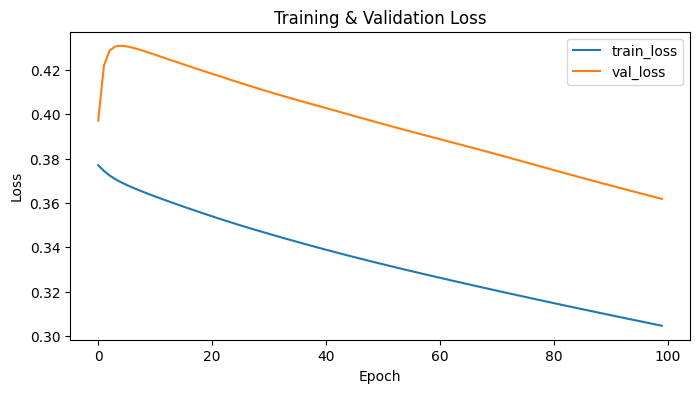

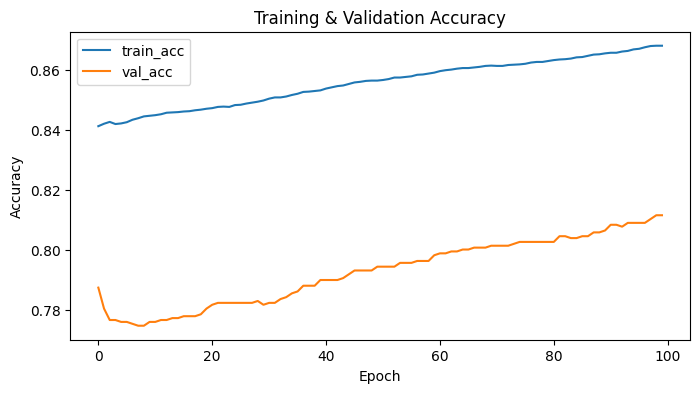

Final train_acc: 0.8679
Final val_acc:   0.8114


In [ ]:
# === @title Этап 9: обучение LSTM-модели ===
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Параметры обучения
epochs = 100
batch_size = 32

# Запуск обучения
history = model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),  # ← вот этого не хватает!
    epochs=epochs,
    batch_size=batch_size,
    verbose=2
)

# --- Отладочные графики ---

# 1) Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],    label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 2) Accuracy
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'],    label='train_acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 3) Финальные метрики
print(f"Final train_acc: {history.history['accuracy'][-1]:.4f}")
print(f"Final val_acc:   {history.history['val_accuracy'][-1]:.4f}")

In [ ]:
# === Этап 10: Метрики ===
def evaluate(y_true, y_pred, y_proba, title=""):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_proba)
    print(f"📌 {title} Metrics")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1       : {f1:.3f}")
    print(f"ROC-AUC  : {auc:.3f}")
    print()
    print(classification_report(y_true, y_pred, digits=3))

# Предсказания и вызов
y_val_pred_proba = model.predict(X_val_lstm, verbose=0)
y_val_pred = (y_val_pred_proba >= 0.5).astype(int).flatten()
evaluate(y_val_lstm, y_val_pred, y_val_pred_proba, title="Validation")

y_test_pred_proba = model.predict(X_test_lstm, verbose=0)
y_test_pred = (y_test_pred_proba >= 0.5).astype(int).flatten()
evaluate(y_test_lstm, y_test_pred, y_test_pred_proba, title="Test")


=== Test Metrics ===
Accuracy : 0.8019
Precision: 0.5333
Recall   : 0.8440
F1-score : 0.6536

=== Confusion Matrix ===
[[1211  322]
 [  68  368]]


📌 Validation Split Metrics
Accuracy : 0.865
Precision: 1.000
Recall   : 0.865
F1       : 0.928
ROC-AUC  : nan

              precision    recall  f1-score   support

           0      0.000     0.000     0.000         0
           1      1.000     0.865     0.928      2452

    accuracy                          0.865      2452
   macro avg      0.500     0.433     0.464      2452
weighted avg      1.000     0.865     0.928      2452

📌 Test Metrics
Accuracy : 0.802
Precision: 0.533
Recall   : 0.844
F1       : 0.654
ROC-AUC  : 0.898

              precision    recall  f1-score   support

           0      0.947     0.790     0.861      1533
           1      0.533     0.844     0.654       436

    accuracy                          0.802      1969
   macro avg      0.740     0.817     0.757      1969
weighted avg      0.855     0.802     0.815      1969



/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being

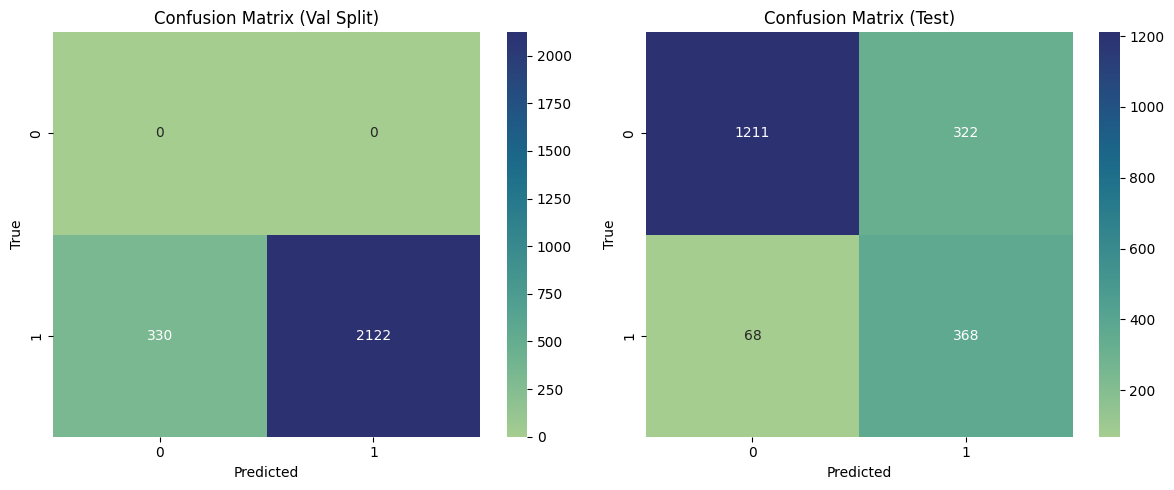

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cm_val = confusion_matrix(y_val_lstm, y_val_pred)
sns.heatmap(cm_val, annot=True, fmt="d", cmap="crest", ax=axs[0])
axs[0].set_title("Confusion Matrix (Validation)")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")

cm_test = confusion_matrix(y_test_lstm, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt="d", cmap="crest", ax=axs[1])
axs[1].set_title("Confusion Matrix (Test)")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("True")

plt.tight_layout()
plt.show()


In [ ]:
# Шаг 1: Настройка callback для сохранения лучших весов
from tensorflow.keras.callbacks import ModelCheckpoint
import os

# Создаём папку для чекпойнтов, если её ещё нет
os.makedirs("checkpoints", exist_ok=True)

# Путь для сохранения лучших весов
checkpoint_path = "checkpoints/lstm_best_weights.h5"

# Callback для сохранения только лучших весов на основе 'val_loss'
cp_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',       # Следим за валидационной метрикой
    save_best_only=True,      # Сохраняем только лучшие веса
    mode='min',               # Минимизируем метрику (например, для val_loss)
    verbose=1,                # Печать, когда сохраняется
    save_freq='epoch'        # Сохраняем после каждой эпохи
)

# Шаг 2: Обучение модели с использованием этого колбэка
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.20,
    shuffle=True,
    callbacks=[cp_callback],  # Добавляем колбэк
    verbose=2
)

# Шаг 3: Сохранение модели целиком и веса
import pickle
from pathlib import Path

# 1) Создаём папку для артефактов
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

# 2) Сохраняем модель целиком (архитектура + веса)
model_path = artifacts_dir / "lstm_eth_fraud_model.h5"
model.save(str(model_path))
print(f"Модель сохранена в {model_path}")

# 3) Сохраняем scaler
scaler_path = artifacts_dir / "scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler сохранён в {scaler_path}")

# 4) Сохраняем список признаков (чтобы при загрузке знать порядок столбцов)
feature_list = X.columns.tolist()  # X – до разбиения, без FLAG
features_path = artifacts_dir / "features_list.pkl"
with open(features_path, "wb") as f:
    pickle.dump(feature_list, f)
print(f"Список признаков сохранён в {features_path}")

# Шаг 4: Извлечение и сохранение эмбеддингов

# Создаём модель для получения эмбеддингов (например, из первого LSTM слоя)
embedding_model = tf.keras.Model(inputs=model.input, outputs=model.layers[0].output)

# Извлекаем эмбеддинги для тренировочных и тестовых данных
embeddings_train = embedding_model.predict(X_train_lstm)
embeddings_test = embedding_model.predict(X_test_lstm)

# Сохраняем эмбеддинги
np.save("artifacts/embeddings_train.npy", embeddings_train)
np.save("artifacts/embeddings_test.npy", embeddings_test)
print(f"Эмбеддинги сохранены в 'artifacts/embeddings_train.npy' и 'artifacts/embeddings_test.npy'")

# Шаг 5: Проверка воспроизводимости (если необходимо)
# Загружаем модель и другие артефакты
model = tf.keras.models.load_model(str(artifacts_dir / "lstm_eth_fraud_model.h5"))
with open(artifacts_dir / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(artifacts_dir / "features_list.pkl", "rb") as f:
    features_list = pickle.load(f)

# Загружаем эмбеддинги (если нужно)
embeddings_train = np.load("artifacts/embeddings_train.npy")
embeddings_test = np.load("artifacts/embeddings_test.npy")

print("Эмбеддинги и модель успешно загружены для дальнейшего использования.")


Epoch 1/100

Epoch 1: val_loss improved from inf to 0.53840, saving model to checkpoints/lstm_best_weights.h5


77/77 - 0s - 2ms/step - accuracy: 0.8225 - loss: 0.4411 - val_accuracy: 0.8658 - val_loss: 0.5384
Epoch 2/100

Epoch 2: val_loss improved from 0.53840 to 0.53651, saving model to checkpoints/lstm_best_weights.h5


77/77 - 0s - 2ms/step - accuracy: 0.8226 - loss: 0.4400 - val_accuracy: 0.8666 - val_loss: 0.5365
Epoch 3/100

Epoch 3: val_loss improved from 0.53651 to 0.53462, saving model to checkpoints/lstm_best_weights.h5


77/77 - 0s - 2ms/step - accuracy: 0.8229 - loss: 0.4389 - val_accuracy: 0.8683 - val_loss: 0.5346
Epoch 4/100

Epoch 4: val_loss improved from 0.53462 to 0.53276, saving model to checkpoints/lstm_best_weights.h5


77/77 - 0s - 2ms/step - accuracy: 0.8230 - loss: 0.4378 - val_accuracy: 0.8683 - val_loss: 0.5328
Epoch 5/100

Epoch 5: val_loss improved from 0.53276 to 0.53091, saving model to checkpoints/lstm_best_weights.h5


...

77/77 - 0s - 2ms/step - accuracy: 0.8431 - loss: 0.3699 - val_accuracy: 0.8793 - val_loss: 0.4346
Epoch 99/100

Epoch 99: val_loss improved from 0.43463 to 0.43391, saving model to checkpoints/lstm_best_weights.h5


77/77 - 0s - 2ms/step - accuracy: 0.8435 - loss: 0.3693 - val_accuracy: 0.8793 - val_loss: 0.4339
Epoch 100/100

Epoch 100: val_loss improved from 0.43391 to 0.43320, saving model to checkpoints/lstm_best_weights.h5


77/77 - 0s - 2ms/step - accuracy: 0.8440 - loss: 0.3688 - val_accuracy: 0.8793 - val_loss: 0.4332


Модель сохранена в artifacts/lstm_eth_fraud_model.h5
Scaler сохранён в artifacts/scaler.pkl
Список признаков сохранён в artifacts/features_list.pkl


AttributeError: The layer sequential_1 has never been called and thus has no defined input.